In [1]:
import os
import sys

PROJECT_NAME = 'sales-forecasting'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'/content/drive/My Drive/Data Science/Personal/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'D:/Data-Science/Projects/Personal/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: D:\Data-Science\Projects\Personal\sales-forecasting


In [2]:
from src.data.data_loader import DataLoader
import matplotlib.pyplot as plt

loader = DataLoader("data/raw/train.csv")
df = loader.load_data()
df.sample(5)

Running in local environment.
Current working directory: D:\Data-Science\Projects\Personal\sales-forecasting
3.0.3


D:\Data-Science\Projects\Personal\sales-forecasting\src\data\data_loader.py:46: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  self.dataFrame = pd.read_csv(self.file_path)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
581612,368,7,2014-01-26,0,0,0,0,0,0
759461,932,2,2013-08-20,6892,703,1,0,0,1
519286,482,7,2014-03-23,0,0,0,0,0,0
282637,528,3,2014-11-12,11406,902,1,1,0,0
748768,274,4,2013-08-29,3071,808,1,1,0,0


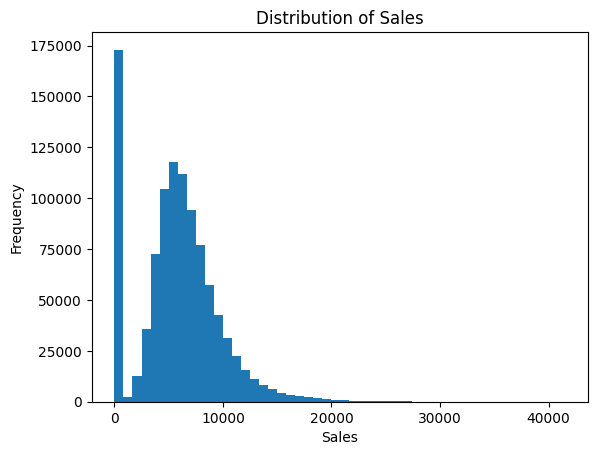

In [3]:
plt.hist(df["Sales"], bins=50)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")
plt.show()

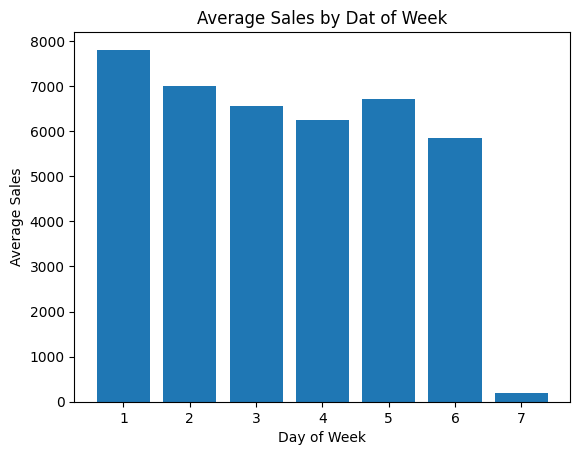

In [4]:
avg_sales_by_day = df.groupby("DayOfWeek")["Sales"].mean()

x = avg_sales_by_day.index
y = avg_sales_by_day.values

plt.bar(x, y)
plt.title("Average Sales by Dat of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.show()

In [5]:
df["Promo"].value_counts()

Promo
0    629129
1    388080
Name: count, dtype: int64

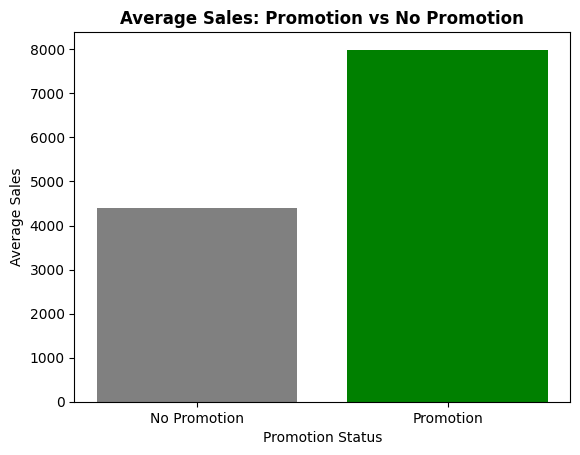

In [6]:
promo_effect = df.groupby("Promo")["Sales"].mean()
plt.bar(promo_effect.index, promo_effect.values, color = ["Gray", "Green"])
plt.xticks([0, 1], ["No Promotion", "Promotion"])
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")
plt.title("Average Sales: Promotion vs No Promotion", fontweight = "bold")
plt.show()


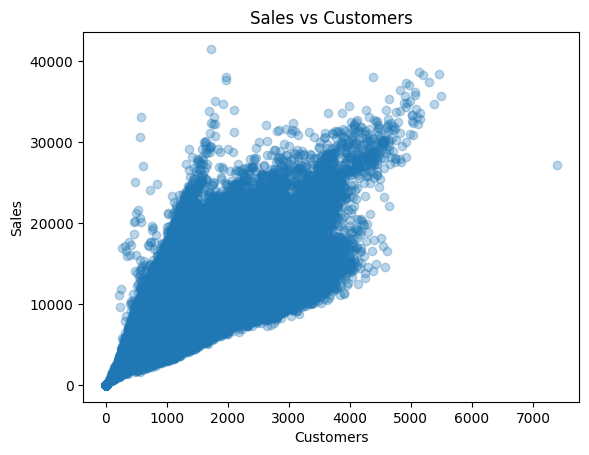

In [7]:
plt.scatter(df["Customers"], df["Sales"], alpha=.3)
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Sales vs Customers")
plt.show()

In [8]:
correlation = df["Customers"].corr(df["Sales"])
print("Correlation between Customers and Sales:", correlation)

Correlation between Customers and Sales: 0.8947107733016959


In [9]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='str')

In [10]:
df["StateHoliday"].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

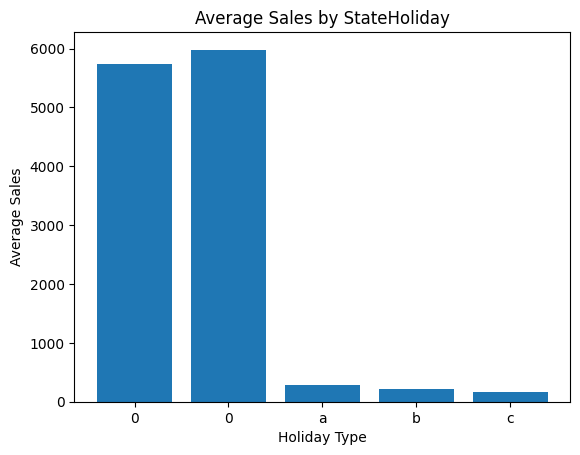

In [11]:
avg_sales_by_holiday = df.groupby("StateHoliday")["Sales"].mean()

x_position = range(len(avg_sales_by_holiday))

plt.bar(x_position, avg_sales_by_holiday.values)
plt.xticks(x_position, avg_sales_by_holiday.index)
plt.xlabel("Holiday Type")
plt.ylabel("Average Sales")
plt.title("Average Sales by StateHoliday")
plt.show()